# Complete Invoice Extraction Workflow

This notebook contains the complete logic used in the Invoice Extraction application. It covers everything from schema definition to the final LangGraph orchestration and visualization.

### 1. Imports and environment setup

In [1]:
import os
import json
from typing import TypedDict, List, Optional
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pypdf import PdfReader
from pdf2image import convert_from_path
import pytesseract
from langchain_openai import ChatOpenAI, AzureChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END
from IPython.display import Image, display

# Load environment variables
load_dotenv(override=True)

True

### 2. Schema Definition
We define the structure of the data we want to extract using Pydantic.

In [2]:
class ProductItem(BaseModel):
    title: str = Field(description="Title or description of the product/service")
    qty: Optional[float] = Field(None, description="Quantity")
    gross_amount: Optional[float] = Field(None, description="Gross amount in ₹")
    discounts_coupons: Optional[float] = Field(None, description="Discounts or coupons in ₹")
    taxable_value: Optional[float] = Field(None, description="Taxable value in ₹")
    igst: Optional[float] = Field(None, description="IGST in ₹")
    total: Optional[float] = Field(None, description="Total amount for this product in ₹")

class InvoiceData(BaseModel):
    invoice_number: str = Field(description="The unique number of the invoice")
    order_id: Optional[str] = Field(None, description="Order ID associated with the invoice")
    order_date: Optional[str] = Field(None, description="Date of the order")
    products: List[ProductItem] = Field(description="List of items/products in the invoice")
    grand_total: float = Field(description="The grand total amount of the invoice")
    gstin: str = Field(description="GST Identification Number")
    billing_address: str = Field(description="The billing address listed on the invoice")
    shipping_address: str = Field(description="The shipping address listed on the invoice")

### 3. PDF and OCR Loader
Handles both native text extraction and OCR for scanned documents.

In [3]:
TESSERACT_CMD = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
if os.path.exists(TESSERACT_CMD):
    pytesseract.pytesseract.tesseract_cmd = TESSERACT_CMD

def extract_text_from_pdf(pdf_path: str) -> str:
    text = ""
    try:
        reader = PdfReader(pdf_path)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text: text += page_text + "\n"
    except Exception as e: print(f"Reader Error: {e}")

    if len(text.strip()) < 50:
        try:
            images = convert_from_path(pdf_path)
            text = ""
            for i, image in enumerate(images):
                text += f"--- Page {i+1} ---\n" + pytesseract.image_to_string(image) + "\n"
        except Exception as e: print(f"OCR Error: {e}")
    return text

### 4. Graph Logic and LLM Setup

In [4]:
class GraphState(TypedDict):
    pdf_path: str
    raw_text: str
    extracted_data: dict
    error: str

def get_llm():
    if os.getenv("OPENAI_API_KEY"): return ChatOpenAI(model="gpt-4o", temperature=0)
    if os.getenv("AZURE_OPENAI_API_KEY"): 
        return AzureChatOpenAI(
            azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
            azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
            api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
            api_key=os.getenv("AZURE_OPENAI_API_KEY"),
            temperature=0
        )
    if os.getenv("GOOGLE_API_KEY"): return ChatGoogleGenerativeAI(model="gemini-1.5-pro", temperature=0)
    raise ValueError("No keys found!")

def extract_text_node(state: GraphState):
    text = extract_text_from_pdf(state["pdf_path"])
    return {"raw_text": text} if text else {"error": "No text!"}

def llm_extraction_node(state: GraphState):
    llm = get_llm().with_structured_output(InvoiceData)
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Extract structured info from the invoice text."),
        ("human", "{text}")
    ])
    result = (prompt | llm).invoke({"text": state["raw_text"]})
    return {"extracted_data": result.dict()}

### 5. Compiled Workflow and Visualization

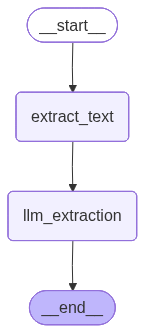

In [5]:
workflow = StateGraph(GraphState)
workflow.add_node("extract_text", extract_text_node)
workflow.add_node("llm_extraction", llm_extraction_node)
workflow.set_entry_point("extract_text")
workflow.add_edge("extract_text", "llm_extraction")
workflow.add_edge("llm_extraction", END)

graph = workflow.compile()

# Visualize the graph
try:
    display(Image(graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    print("Visualization requires additional dependencies (e.g., pygraphviz or a mermaid render service).")
    print("Graph Nodes:", graph.get_graph().nodes)
    print("Graph Edges:", graph.get_graph().edges)

### 6. Execution Example

In [7]:
def process_invoice_ipynb(pdf_path: str):
    res = graph.invoke({"pdf_path": pdf_path, "raw_text": "", "extracted_data": {}, "error": ""})
    return res.get("extracted_data")

test_pdf = r"C:\Users\bsmun\Downloads\OD435588196413169100-1.pdf"
if os.path.exists(test_pdf):
    print(json.dumps(process_invoice_ipynb(test_pdf), indent=2))

{
  "invoice_number": "FAETL62600285389",
  "order_id": "OD435588196413169100",
  "order_date": "2025-09-28",
  "products": [
    {
      "title": "CASIO GA-2100BM-7A2DR G-SHOCK Analog-Digital Watch - For Men",
      "qty": 1.0,
      "gross_amount": 7285.0,
      "discounts_coupons": 0.0,
      "taxable_value": 6173.73,
      "igst": 1111.27,
      "total": 7285.0
    }
  ],
  "grand_total": 7285.0,
  "gstin": "29AABCW4360P1ZP",
  "billing_address": "Susilasusindhra, #132, opp RKN electionic, BDO Office bus stop, pennagaram, Pennagaram 636810 Tamil Nadu",
  "shipping_address": "Susilasusindhra, #132, opp RKN electionic, BDO Office bus stop, pennagaram, Pennagaram 636810 Tamil Nadu"
}


C:\Users\bsmun\AppData\Local\Temp\ipykernel_20716\2000411078.py:31: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  return {"extracted_data": result.dict()}
